# Workshop: Rapid Application Development using Large Language Models
## Part 1: From Deep Learning to LLMs and Encoders

Practical session (60 min)

This notebook is part of a workshop based on NVIDIA DLI materials
"Rapid Application Development using Large Language Models",
adapted for Google Colab with a T4 GPU.

Credits: Original course materials by NVIDIA Corporation / NVIDIA Deep Learning Institute.

### Learning Objectives

By the end of this notebook you will be able to:

- Explain what a tokenizer does and read its output
- Describe how word embeddings and positional encodings represent text
- Visualize attention weights in a BERT encoder
- Use pre-trained encoder models for three NLP tasks:
  sentiment analysis, named entity recognition, and zero-shot classification

In [1]:
# Run this cell first to install required packages
!pip install -q transformers datasets seaborn

In [2]:
import torch

device = 0 if torch.cuda.is_available() else -1
print("GPU available:", torch.cuda.is_available())
if device == 0:
    print("GPU model  :", torch.cuda.get_device_name(0))
    print("GPU memory :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

GPU available: True
GPU model  : Tesla T4
GPU memory : 15.6 GB


---

## Part 1.1: The Tokenizer

A transformer model cannot work with raw text.
First, the text is split into small pieces called **tokens**.
Each token is then mapped to a number (its ID).
This process is done by the **tokenizer**.

BERT uses **WordPiece tokenization**.
Common words become a single token.
Rare or unknown words are split into smaller pieces.
For example: `"unbelievable"` becomes `["un", "##believe", "##able"]`.
The `##` prefix means the piece continues the previous word.

The tokenizer returns three things:

| Output | What it is |
|---|---|
| `input_ids` | The number (ID) for each token |
| `attention_mask` | 1 for real tokens, 0 for padding |
| `token_type_ids` | Segment label (used when two texts are given together) |

Two special tokens are always added:
- `[CLS]` at the start: its final output vector is used for text classification
- `[SEP]` at the end: marks the end of a text segment

In [12]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "bert-base-uncased"

# Other encoder models that run on Google Colab (T4):
#
# Smaller and faster:
#   "distilbert-base-uncased"      40% smaller than BERT, 60% faster, similar results
#   "albert-base-v2"               very small (12M params), good for low-memory setups
#
# Same size, different training:
#   "bert-base-cased"              same as bert-base but keeps uppercase letters
#   "roberta-base"                 improved BERT training, usually better results
#   "google/electra-base-discriminator"  efficient alternative training method
#
# Multilingual (one model for many languages):
#   "bert-base-multilingual-cased"  104 languages
#   "xlm-roberta-base"              100 languages, stronger than multilingual BERT
#
# Larger (still fit on T4, slower):
#   "bert-large-uncased"           340M params
#   "roberta-large"                355M params
#   "microsoft/deberta-v3-base"    strong results on many benchmarks

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager"  # needed for output_attentions=True
).to("cuda")
model.eval()
print("Model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [13]:
text = "The workshop on large language models starts today."
encoding = tokenizer(text, return_tensors="pt")

tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

print("Tokens:", tokens)
print("Input IDs:", encoding["input_ids"][0].tolist())
print("Attention mask:", encoding["attention_mask"][0].tolist())

Tokens: ['[CLS]', 'the', 'workshop', 'on', 'large', 'language', 'models', 'starts', 'today', '.', '[SEP]']
Input IDs: [101, 1996, 8395, 2006, 2312, 2653, 4275, 4627, 2651, 1012, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [14]:
# WordPiece splits rare words into smaller pieces
# This is used by BERT and DistilBERT.
#
# Other tokenization methods:
#
#   Byte-Pair Encoding (BPE)
#     Starts with characters, then merges the most common pairs step by step.
#     Used by: GPT-2, RoBERTa, LLaMA, Mistral
#     Example: "running" -> ["run", "ning"]
#
#   Byte-level BPE
#     Same as BPE but works on raw bytes instead of characters.
#     Handles any language and emoji without unknown tokens.
#     Used by: GPT-2, GPT-3, GPT-4
#
#   SentencePiece
#     Treats the whole text as a stream (no pre-splitting on spaces).
#     Works well for languages without clear word boundaries (e.g. Japanese, Chinese).
#     Used by: T5, LLaMA, mT5, Gemma
#     Example: "Hello world" -> ["_Hello", "_world"]  (_ marks a space)
#
#   Unigram
#     Starts with a large vocabulary and removes less useful tokens step by step.
#     Used by: T5 (via SentencePiece), XLNet, ALBERT
#
# All methods have the same goal: find a small vocabulary that can represent any text.

examples = ["tokenization", "transformers", "supercalifragilistic", "NVIDIA", "NLP"]

print(f"{'Word':<28} Tokens")
print("-" * 55)
for word in examples:
    toks = tokenizer.tokenize(word)
    print(f"  {word:<26} {toks}")

Word                         Tokens
-------------------------------------------------------
  tokenization               ['token', '##ization']
  transformers               ['transformers']
  supercalifragilistic       ['super', '##cal', '##if', '##rag', '##ilis', '##tic']
  NVIDIA                     ['n', '##vid', '##ia']
  NLP                        ['nl', '##p']


---

## Part 1.2: Word Embeddings and Positional Encoding

Each token ID is looked up in a table and converted to a vector with 768 numbers.
This vector is called a **word embedding**. It tries to capture the meaning of the token.

Before the first transformer block, two types of vectors are added together:

- **Word embeddings**: what the token means
- **Positional embeddings**: where the token appears in the sequence

Positional embeddings are important because transformers process all tokens at the same time.
Without position information, the model cannot tell "cat bit dog" from "dog bit cat".

We can measure how similar two vectors are using **cosine similarity**.
The value is between -1 (completely different direction) and +1 (same direction).

In [15]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def cosine_similarity(a, b):
    # Compute pairwise cosine similarity between two sets of vectors
    a_n = a / (a.norm(dim=1, keepdim=True) + 1e-8)
    b_n = b / (b.norm(dim=1, keepdim=True) + 1e-8)
    return (a_n @ b_n.T).numpy()

def plot_heatmap(matrix, labels, title, figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    annotate = len(labels) <= 14
    sns.heatmap(
        matrix,
        xticklabels=labels, yticklabels=labels,
        cmap="RdYlGn", vmin=-1, vmax=1,
        annot=annotate, fmt=".2f", annot_kws={"size": 7},
        ax=ax,
    )
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Tokens: ['[CLS]', 'hello', 'world', 'from', 'the', 'university', 'workshop', '!', '[SEP]']
Embedding shape: torch.Size([9, 768])  <- one 768-number vector per token


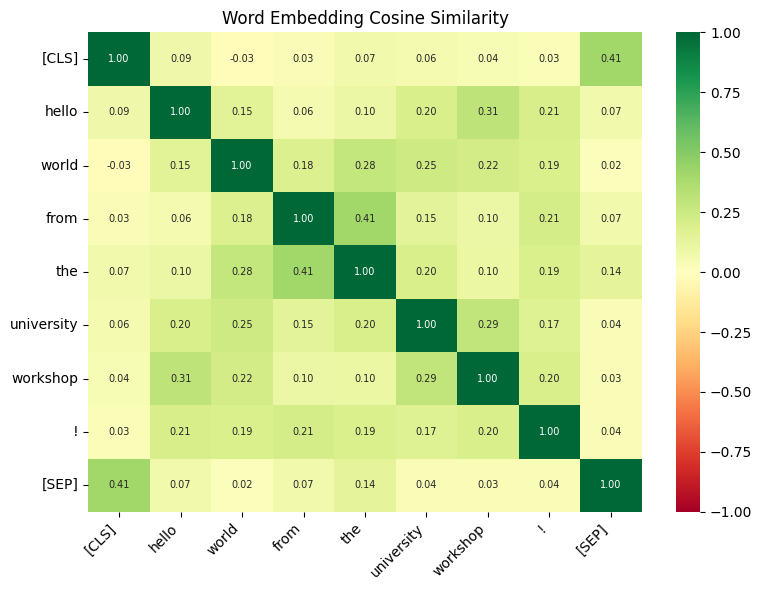

In [16]:
text = "Hello world from the university workshop!"
encoding = tokenizer(text, return_tensors="pt").to("cuda")
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

# Get raw word embeddings (before positional encoding is added)
with torch.no_grad():
    word_embeds = model.embeddings.word_embeddings(encoding["input_ids"])

word_embeds = word_embeds[0].cpu()  # shape: [num_tokens, 768]
print("Tokens:", tokens)
print("Embedding shape:", word_embeds.shape, " <- one 768-number vector per token")

sim = cosine_similarity(word_embeds, word_embeds)
plot_heatmap(sim, tokens, "Word Embedding Cosine Similarity")

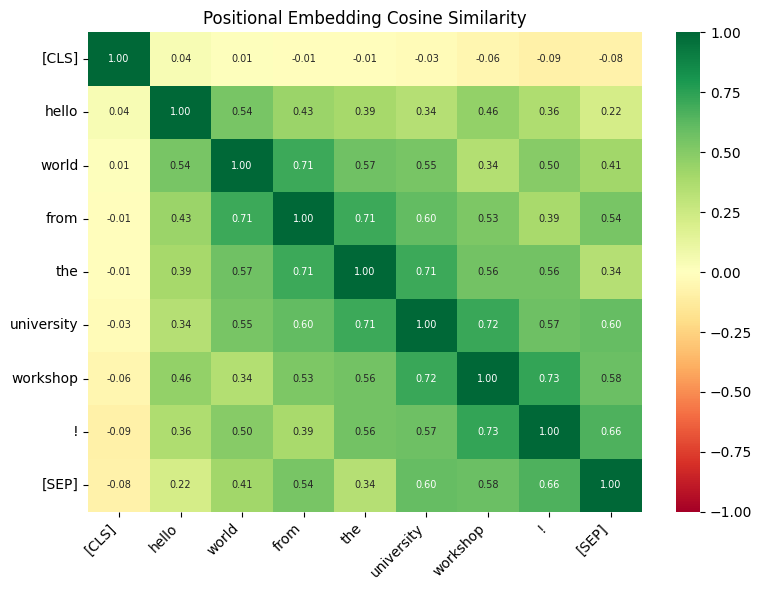

Note: nearby positions are more similar to each other.
This is very different from word embeddings, which group by meaning.


In [17]:
# Positional embeddings only depend on position, not on the word
positions = torch.arange(len(tokens)).to("cuda")
with torch.no_grad():
    pos_embeds = model.embeddings.position_embeddings(positions).cpu()

sim_pos = cosine_similarity(pos_embeds, pos_embeds)
plot_heatmap(sim_pos, tokens, "Positional Embedding Cosine Similarity")

print("Note: nearby positions are more similar to each other.")
print("This is very different from word embeddings, which group by meaning.")

---

## Part 1.3: Attention Mechanism

After the embeddings, BERT passes the token vectors through **12 transformer blocks**.
The key part of each block is **self-attention**.

Self-attention lets every token look at every other token and decide how much
to borrow from it. The result is a new vector for each token that mixes in
information from the whole sentence.

BERT uses **multi-head attention**: it runs 12 different attention patterns in parallel.
Each head learns to focus on different things.
For example, one head might track which pronoun refers to which noun.
Another head might track subject-verb pairs.

With 12 layers and 12 heads, BERT has 144 attention patterns in total.

Below, we run a forward pass and plot one attention head from the last layer.
Try changing `layer_idx` and `head_idx` to explore different patterns.

In [18]:
text = "The cat sat on the mat and it was very happy."
encoding = tokenizer(text, return_tensors="pt").to("cuda")
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

with torch.no_grad():
    outputs = model(**encoding, output_attentions=True)

# outputs.attentions is a list of 12 tensors, one per layer
# each tensor has shape: [batch, heads, seq_len, seq_len]
print("Number of layers :", len(outputs.attentions))
print("Attention shape  :", tuple(outputs.attentions[0].shape), " [batch, heads, seq, seq]")

Number of layers : 12
Attention shape  : (1, 12, 14, 14)  [batch, heads, seq, seq]


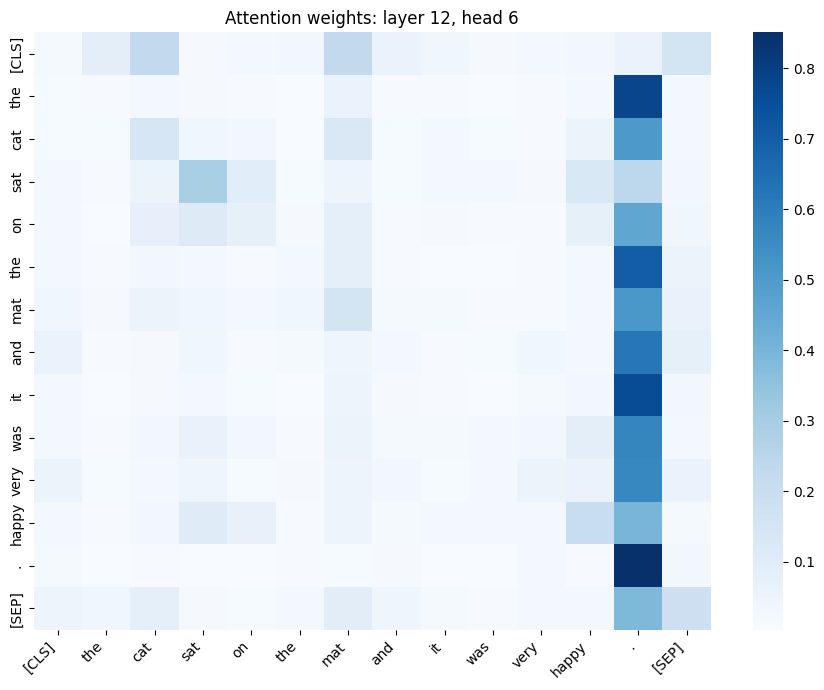

Tip: look at the row for 'it' and see which token it pays most attention to.


In [19]:
layer_idx = 11   # change this: 0 to 11
head_idx = 5     # change this: 0 to 11

attn = outputs.attentions[layer_idx][0, head_idx].cpu().numpy()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap="Blues", ax=ax)
ax.set_title(f"Attention weights: layer {layer_idx + 1}, head {head_idx + 1}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Tip: look at the row for 'it' and see which token it pays most attention to.")

---

## Exercises: Encoder Tasks in Practice

The next three exercises use the HuggingFace `pipeline` API.
A pipeline combines three steps into one simple function call:

1. Tokenizer: converts text to numbers
2. Model: runs the numbers through the network
3. Postprocessor: converts the output numbers into a readable result

We free GPU memory between exercises to stay within the T4 limit.

In [20]:
import gc

del model
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")
print("Available:", round(torch.cuda.mem_get_info()[0] / 1e9, 1), "GB")

GPU memory freed.
Available: 15.5 GB


---

### Exercise 1: Multilingual Sentiment Analysis

The model `nlptown/bert-base-multilingual-uncased-sentiment` was trained on
product reviews in six languages: English, German, Dutch, French, Spanish, and Italian.
It returns a star rating from 1 to 5.

Note: because it was trained on product reviews, it may be less accurate for other types of text like news, social media, or academic writing.

**Tasks:**
1. Run the examples and read the output
2. Add at least two sentences of your own, including one in a language other than English
3. Try a sarcastic sentence (saying the opposite of what you mean) and check the result

In [21]:
from transformers import pipeline

sentiment = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0,
)

sentences = [
    "This workshop is very well organized!",
    "The coffee machine is broken again.",
    "Das Essen war ausgezeichnet.",                      # German: The food was excellent.
    "Le service etait correct, mais pas exceptionnel.", # French: The service was ok, not great.
    # TODO: add your own sentences here
]

print(f"{'Sentence':<52} {'Stars':<10} Score")
print("-" * 75)
for sent in sentences:
    r = sentiment(sent)[0]
    print(f"{sent:<52} {r['label']:<10} {r['score']:.4f}")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Sentence                                             Stars      Score
---------------------------------------------------------------------------
This workshop is very well organized!                5 stars    0.7221
The coffee machine is broken again.                  1 star     0.4340
Das Essen war ausgezeichnet.                         5 stars    0.5874
Le service etait correct, mais pas exceptionnel.     3 stars    0.6836


In [22]:
del sentiment
gc.collect()
torch.cuda.empty_cache()

---

### Exercise 2: Named Entity Recognition (NER)

The model `dslim/bert-base-NER` was trained on the CoNLL-2003 dataset.
It reads a text and labels each word with one of these types:

| Label | Meaning |
|---|---|
| PER | A person's name |
| ORG | An organization |
| LOC | A location |
| MISC | Other named things (events, nationalities, etc.) |

`aggregation_strategy="simple"` joins word pieces back into full words.

**Tasks:**
1. Run the example and check the output
2. Write 2 to 3 sentences with at least one entity of each type
3. Try a word that could be both a place name and a common word (for example, "Amazon")

In [24]:
from transformers import pipeline

ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=0,
)

text = (
    "Jani Dugonik works at the University of Maribor in Slovenia. "
    "He will present his research in Sweden next August."
)

entities = ner(text)

print("Text:", text, "\n")
print(f"{'Entity':<25} {'Type':<10} Score")
print("-" * 48)
for ent in entities:
    print(f"{ent['word']:<25} {ent['entity_group']:<10} {ent['score']:.4f}")

# TODO: try your own text
# my_text = "..."
# for ent in ner(my_text):
#     print(ent)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text: Jani Dugonik works at the University of Maribor in Slovenia. He will present his research in Sweden next August. 

Entity                    Type       Score
------------------------------------------------
Jan                       PER        0.9996
##i Dugonik               PER        0.8815
University of Maribor     ORG        0.9933
Slovenia                  LOC        0.9998
Sweden                    LOC        0.9997


In [25]:
del ner
gc.collect()
torch.cuda.empty_cache()

---

### Exercise 3: Zero-Shot Classification

A normal classifier needs training data for every category.
**Zero-shot classification** does not.

It works by turning the task into a question:
"Does this text match the topic [label]?"

This is called **Natural Language Inference (NLI)**.
The model was never trained on your labels.
It uses its general language knowledge to decide.

**Tasks:**
1. Run the example and read the scores
2. Add two more labels and see how the scores change
3. Try a very short sentence and explain the model result

In [27]:
from transformers import pipeline

# Other zero-shot classification models for Colab T4:
#   "facebook/bart-large-mnli"                        standard choice, ~1.6 GB
#   "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"    smaller, ~750 MB, strong results
#   "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"         multilingual version, ~750 MB
#   "cross-encoder/nli-deberta-v3-small"              smallest option, ~250 MB

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0,
)

text = (
    "Researchers have developed a new neural network architecture that achieves "
    "state-of-the-art results on several language benchmarks while reducing "
    "computational cost by 40 percent."
)

candidate_labels = [
    "artificial intelligence",
    "sports",
    "politics",
    "scientific research",
    "economy",
    # TODO: add more labels here and see how the scores change
]

result = classifier(text, candidate_labels)

print("Text:", text[:90], "...\n")
print(f"{'Label':<28} {'Score':>6}  Bar")
print("-" * 55)
for label, score in zip(result["labels"], result["scores"]):
    bar = "#" * int(score * 40)
    print(f"{label:<28} {score:.4f}  {bar}")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Text: Researchers have developed a new neural network architecture that achieves state-of-the-ar ...

Label                         Score  Bar
-------------------------------------------------------
artificial intelligence      0.6308  #########################
scientific research          0.2714  ##########
economy                      0.0833  ###
sports                       0.0093  
politics                     0.0052  


In [28]:
del classifier
gc.collect()
torch.cuda.empty_cache()

---

## Wrapping Up

In this notebook you have:

- Loaded BERT and seen how the tokenizer converts text into token IDs
- Plotted word embeddings and positional encodings using cosine similarity
- Looked at attention weights and seen how tokens relate to each other
- Used three pre-trained encoder models with HuggingFace pipelines

**Key points:**

- Encoder models work well when the full context of a sentence is needed at once
- The same pre-trained model can do many tasks by changing only the task head
- Zero-shot classification works because the model has learned general language patterns

**Part 2** covers decoder models and shows how models generate text one token at a time.

In [1]:
# Run this cell before opening the Part 2 notebook
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}